In [3]:
import os

# mount drive if colab
from google.colab import drive
drive.mount('/content/gdrive')
os.chdir("/content/gdrive/MyDrive/Soil_Moisture/Local_Training")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
import os
import numpy as np
import tensorflow as tf


OUTPUT_NAME = "Fine_Tuning_Osiris" 
Grandvillers_path = '/content/gdrive/My Drive/Grandvillers/Grandvillers'
ROOT_DIR = "/content/gdrive/MyDrive/Soil_Moisture/dataset_training" # Si on Colab
OSIRIS_DIR = os.path.join(ROOT_DIR, "Osiris_dataset")

drive_dir = os.path.join("/content/gdrive/MyDrive/Soil_Moisture/outputs", OUTPUT_NAME) # Si on Colab
RESULTS_CSV_PATH = os.path.join(drive_dir, "results.csv") # Si on Colab


# FOLDER_NAME = "Fine_Tuning" 

# ROOT_DIR = "/home/theo/Dataset" # Si on local machine

# OSIRIS_DIR = os.path.join(ROOT_DIR, "Osiris_dataset")

# Grandvillers_path = os.path.join(ROOT_DIR, "Grandvillers_data")

# drive_dir = os.path.join("/home/theo/Documents", FOLDER_NAME, "outputs") # Si on local machine

# RESULTS_CSV_PATH = os.path.join(drive_dir, "results.csv") # Si on local machine

# ============================================================
# Configuration
# ============================================================

FOLDER_ISMN = "station_depth_csv"
MASTER_CSV_PATH = os.path.join(ROOT_DIR, FOLDER_ISMN, "Soil_Properties_Master.csv")

base_path = os.path.join(ROOT_DIR, FOLDER_ISMN, "depth")

FULL_DENSE_h = [ "soil_moisture", "ET0", "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",
              "VPD", "T_RANGE",
              "RAIN_CUM_3D", "RAIN_CUM_7D", "RAIN_CUM_14D",
              "doy_sin", "doy_cos"]

FULL_DENSE = [  "ET0", "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",
              "VPD", "T_RANGE",
              "RAIN_CUM_3D", "RAIN_CUM_7D", "RAIN_CUM_14D",
              "doy_sin", "doy_cos"]

FULL_SOIL  = [ "clay", "silt", "bulk", "sand", "dem", "ksat_m_1km", "dem_slope", "dem_aspect", "dem_twi"]

FULL_SPARSE = ["S2_B2", "S2_B3", "S2_B4", "S2_B5", "S2_B6", "S2_B7",
               "S2_B8", "S2_B8A", "S2_B11", "S2_B12",
               "S2_NDVI", "S2_NDWI", "S2_SAVI", "S2_MNDWI", "S2_NBR",
               "S1_VV", "S1_VH", "S1_angle",
               "S1_VV_over_VH", "S1_VH_over_VV",
               "HLS_B2", "HLS_B3", "HLS_B4", "HLS_B5", 
                     "HLS_B6", "HLS_B7", "HLS_B9", "HLS_B10", "HLS_B11", "HLS_NDVI"]

FULL_SPARSE_S1 = ["S1_VV", "S1_VH", "S1_angle",
                   "S1_VV_over_VH", "S1_VH_over_VV"]

FULL_SPARSE_S2 = ["S2_B2", "S2_B3", "S2_B4", "S2_B5", "S2_B6", "S2_B7",
               "S2_B8", "S2_B8A", "S2_B11", "S2_B12",
               "S2_NDVI", "S2_NDWI", "S2_SAVI", "S2_MNDWI", "S2_NBR"]

FULL_SPARSE_HLS30 = ["HLS_B2", "HLS_B3", "HLS_B4", "HLS_B5", 
                     "HLS_B6", "HLS_B7", "HLS_B9", "HLS_B10", "HLS_B11", "HLS_NDVI"]

# Training settings
HORIZONS = [7]              # predict * days ahead 
LOOKBACK = [7]                  # use past * days to predict next day
DEPTHS = [ 0.1 ]#, 0.4, 0.5] # 0.5]
        #    0.3, 0.4, 0.5]  # we will loop over these depths and train one model per depth
ALL_NETWORKS = [
    "all"]

    # ["COSMOS-UK", "GROW", "PTSMN", "TAHMO", "TERENO"]
SEPARATE_NETWORKS = [

    #  ["COSMOS-UK"],
             ["DWD"],
            #  ["FR_Aqui", "GROW"],
             ["PTSMN"], 
            ["SMOSMANIA"], 
            ["SOILSCAPE"],
            # ["TAHMO","TERENO"],
        # ["TERENO"], 
            # ["TWENTE"], 
            # ["XMS-CAT"]
        ]

NETWORK1 = [
            ["TAHMO","TERENO","FR_Aqui"],
            ["TAHMO","TERENO","GROW"],
            ["TAHMO","TERENO","GROW","FR_Aqui"]
        ]


NB_WINDOWS = [100000]    
# Models: xgboost and lightgbm are fast, non-DL
MODELS = ["lstm"]
# , "lightgbm"]

def _without(lst, *items):
    return [x for x in lst if x not in items]

FEATURE_CONFIGS = [


    # # ── 4.2.1 Comparaison des modèles ──
    # {"name": "Models", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE,
    #  "lookbacks": [7], "horizons": [7], "depths": DEPTHS, "nb_windows": [50000],
    #  "models": ["xgboost", "lightgbm", "lstm", "gru", "tcn", "transformer"],
    #  "networks": ALL_NETWORKS},

#     # ── 4.2.2 Effet du lookback ──
#     {"name": "Lookback", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE_S1,
#      "lookbacks": [1, 2, 4, 7, 14, 21, 28],
#      "horizons": [7], "depths": DEPTHS, "nb_windows": [50000],
#      "models": ["xgboost", "lstm"],
#      "networks": ALL_NETWORKS},

#     # ── 4.2.3 Effet de l'horizon ──
#     {"name": "Horizon", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE_S1,
#      "lookbacks": [7],
#      "horizons": [1, 3, 7, 14, 21],
#      "depths": DEPTHS, "nb_windows": [50000],
#      "models": ["xgboost", "lstm"],
#      "networks": ALL_NETWORKS},

#     # ── 4.2.4 Effet du nombre de fenêtres ──
#     {"name": "Nb_Windows", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE_S1,
#      "lookbacks": [7], "horizons": [7], "depths": DEPTHS,
#      "nb_windows": [1000, 5000, 10000, 20000, 50000, 100000],
#      "models": ["xgboost", "lstm"],
#      "networks": ALL_NETWORKS},

    {"name": "Network_FT", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE,
     "lookbacks": [7], "horizons": [7], "depths": DEPTHS, "nb_windows": [50000],
        "models": ["lstm"],
        "networks": NETWORK1},

#     # ── 4.2.6 Importance de la proximité géographique (par réseau) ──
#     {"name": "Networks", "dense": FULL_DENSE, "soil": FULL_SOIL, "sparse": FULL_SPARSE_S1,
#      "lookbacks": [7], "horizons": [7], "depths": DEPTHS, "nb_windows": [50000],
#      "models": ["xgboost"],
#      "networks": SEPARATE_NETWORKS},
]

SAVE_PLOTS = True
SAVE_NETWORKS_DIR = True
SAVE_MODELS_DIR = True
SAVE_RESULTS_CSV = True



TARGET_COL = "soil_moisture"
DATE_COL = "date_time"  # L'index temporel est sauvegardé sous date_time par process_timeseries
EPOCHS = 150
BATCH_SIZE = 32
SEED = 8

if SAVE_MODELS_DIR:
    os.makedirs(drive_dir, exist_ok=True)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# MONTHS=[4,5,6,7,8,9]
MONTHS = None

In [5]:
from Fcn_Training import (full_training, 
                        get_osiris_data,
                        Get_Grandvillers_data,
                        prepare_era5_dataset,
                        osiris_train,
                        osiris_fine_tuning,
                        full_eval_grandvillers,
                        full_eval_osiris)

Chargement des fichiers Grandvillers depuis: /content/gdrive/My Drive/Grandvillers/Grandvillers/Grandvillers_satellites
-> 6 sondes/fichiers chargés et prêts pour l'évaluation.

--- PRÉPARATION DU JEU DE TEST ERA5 ---

--- Comparaison (113 jours en commun pour Fichier 0) ---
• TMAX:  RMSE = 1.83 | MAE = 1.51 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.43 | Biais = -1.29 (Local - ERA5)
• RAIN:  RMSE = 4.91 | MAE = 1.83 | Biais = 0.40 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2748.12 | MAE = 2091.27 | Biais = 468.51 (Local - ERA5)
• WIND:  RMSE = 5.78 | MAE = 4.63 | Biais = 2.01 (Local - ERA5)


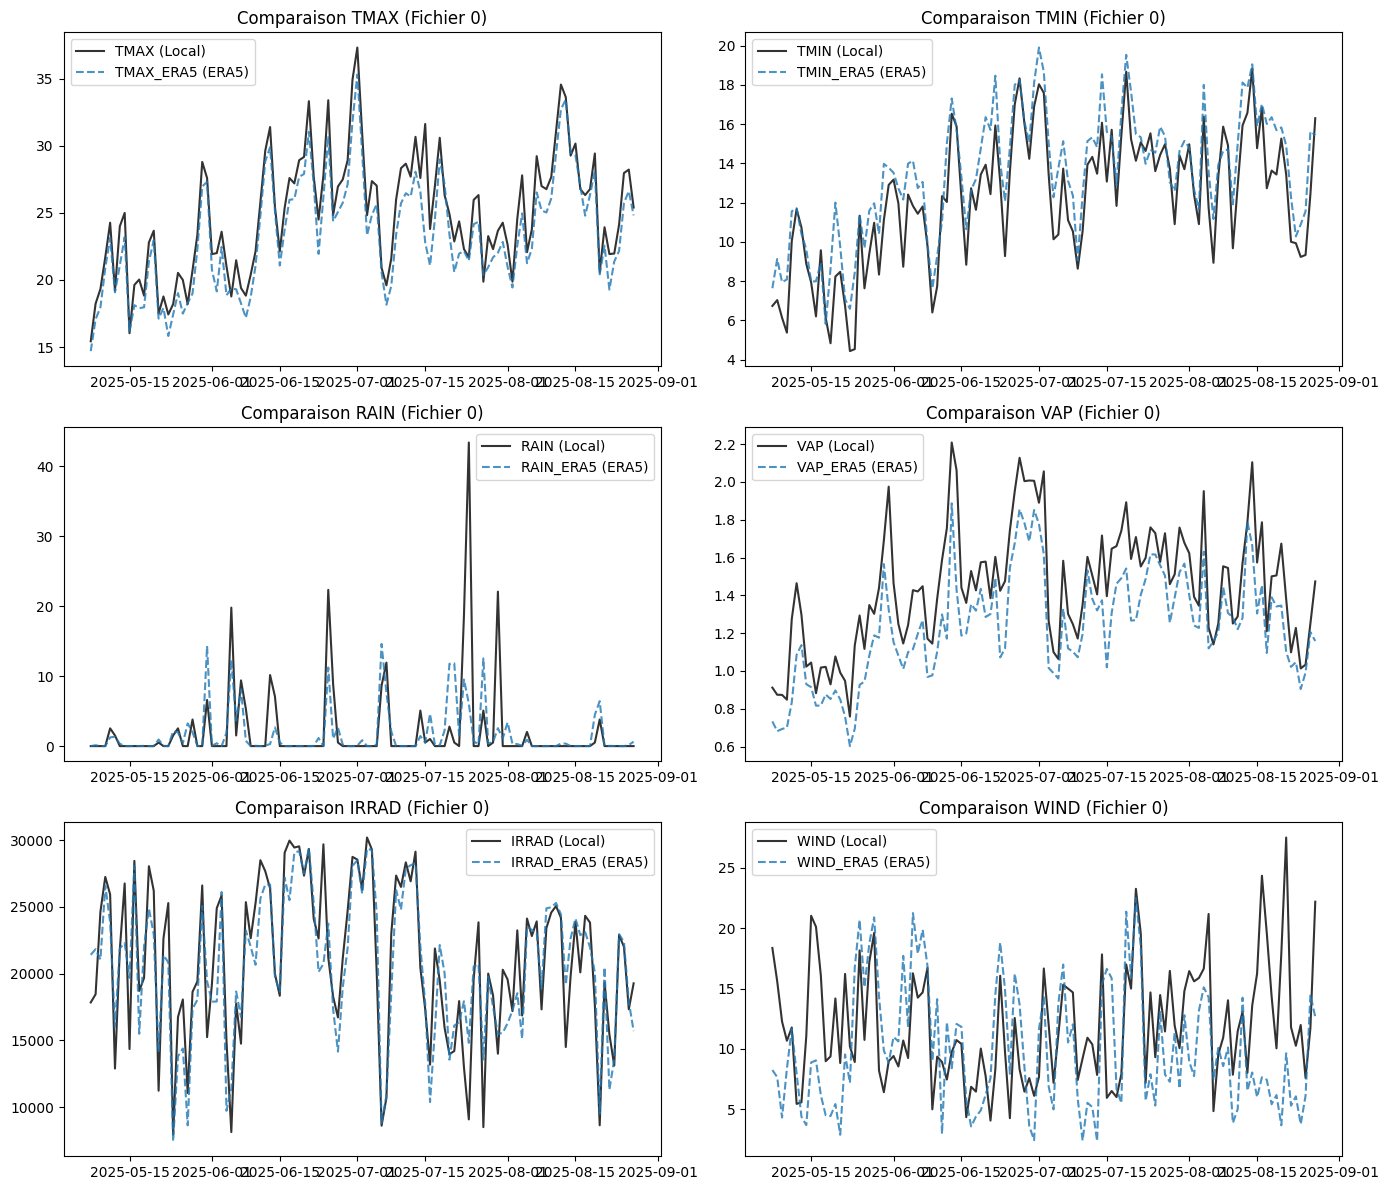


--- Comparaison (115 jours en commun pour Fichier 1) ---
• TMAX:  RMSE = 1.82 | MAE = 1.50 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.44 | Biais = -1.30 (Local - ERA5)
• RAIN:  RMSE = 4.87 | MAE = 1.80 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2770.02 | MAE = 2118.19 | Biais = 523.65 (Local - ERA5)
• WIND:  RMSE = 5.93 | MAE = 4.75 | Biais = 2.17 (Local - ERA5)


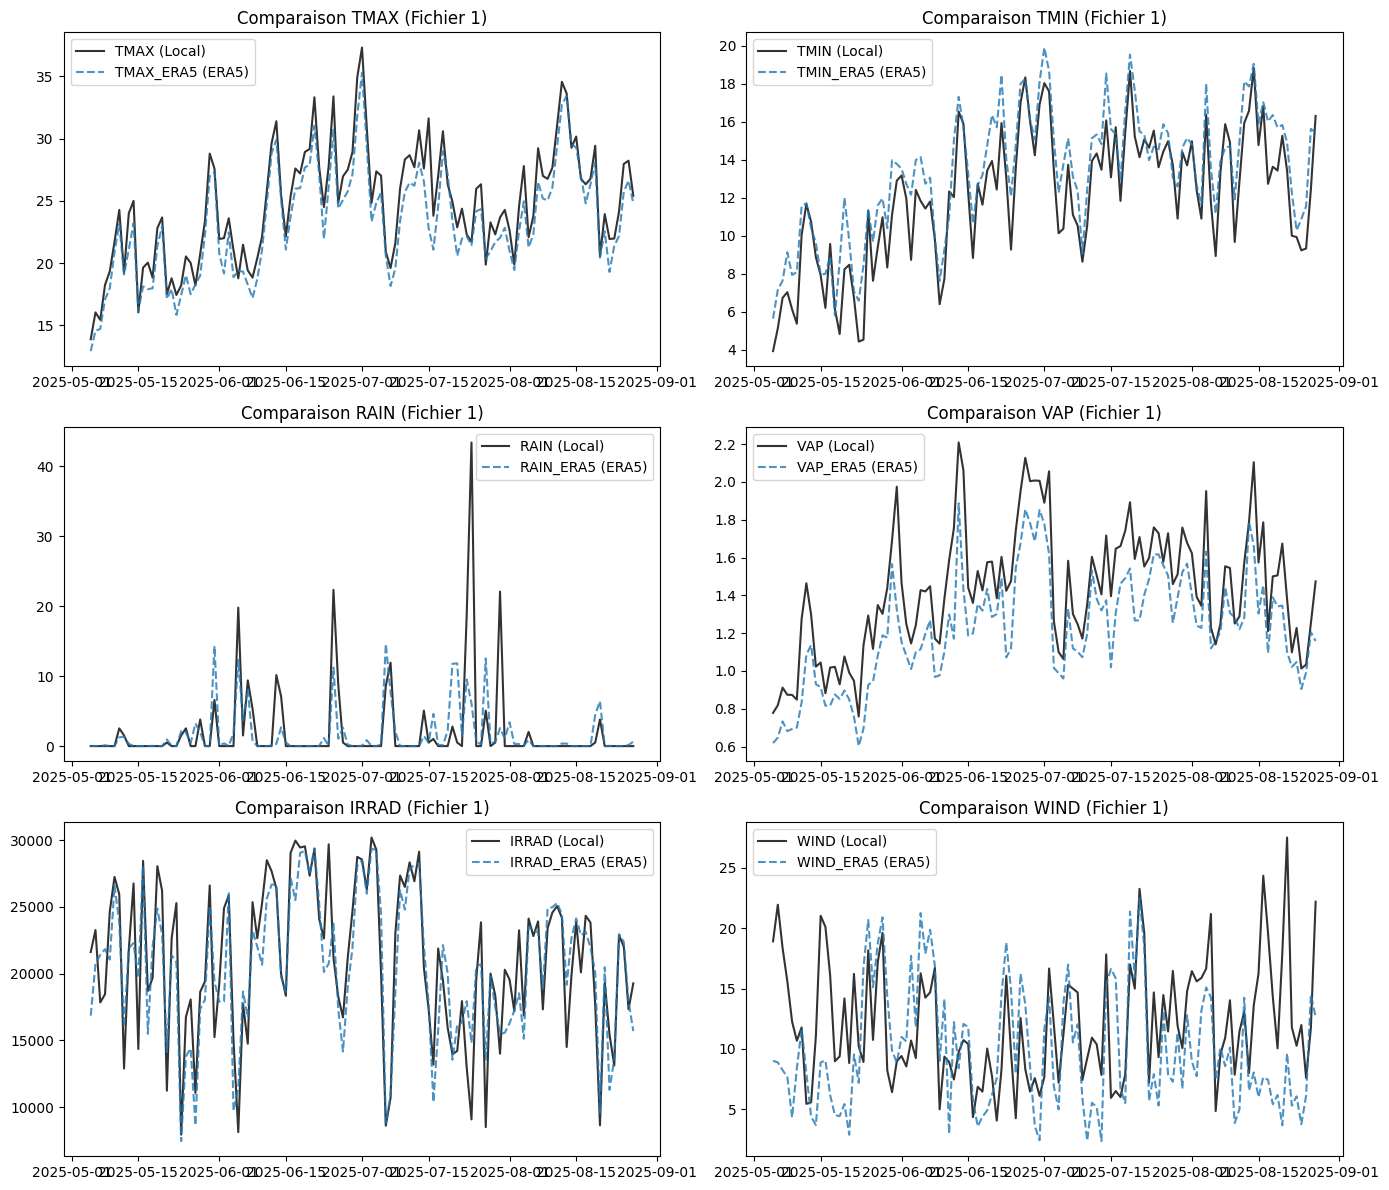


--- Comparaison (115 jours en commun pour Fichier 2) ---
• TMAX:  RMSE = 1.82 | MAE = 1.50 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.44 | Biais = -1.30 (Local - ERA5)
• RAIN:  RMSE = 4.87 | MAE = 1.80 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2770.02 | MAE = 2118.19 | Biais = 523.65 (Local - ERA5)
• WIND:  RMSE = 5.93 | MAE = 4.75 | Biais = 2.17 (Local - ERA5)


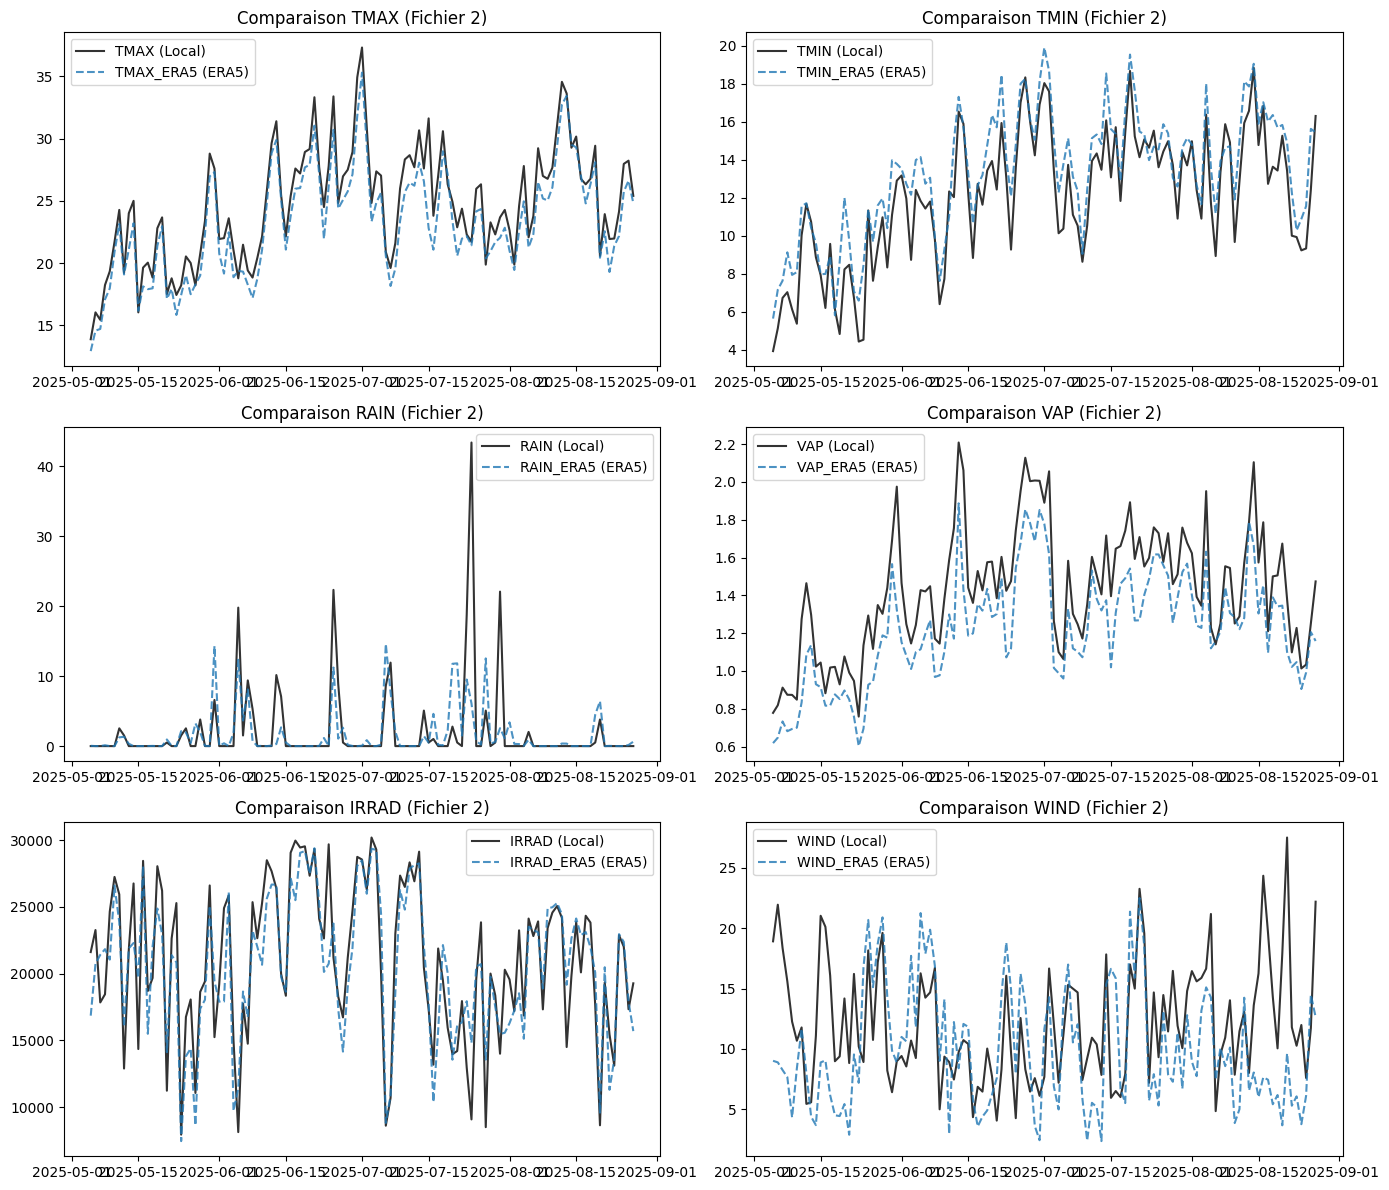


--- Comparaison (115 jours en commun pour Fichier 3) ---
• TMAX:  RMSE = 1.82 | MAE = 1.50 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.44 | Biais = -1.30 (Local - ERA5)
• RAIN:  RMSE = 4.87 | MAE = 1.80 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2770.02 | MAE = 2118.19 | Biais = 523.65 (Local - ERA5)
• WIND:  RMSE = 5.93 | MAE = 4.75 | Biais = 2.17 (Local - ERA5)


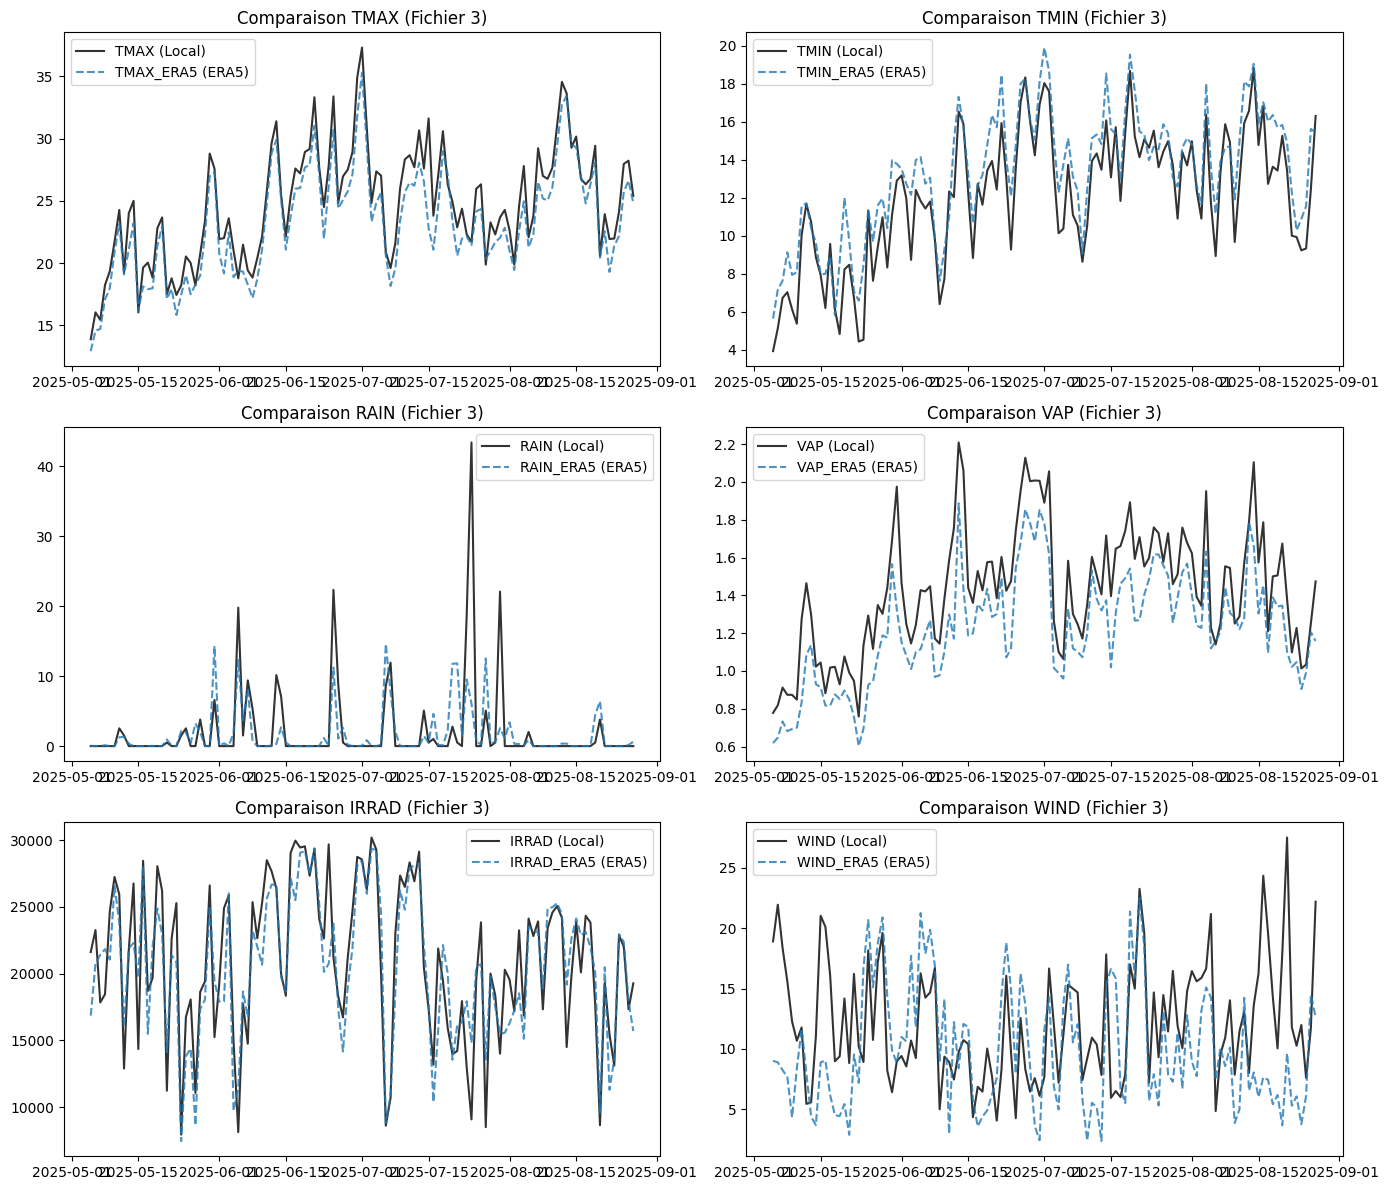


--- Comparaison (116 jours en commun pour Fichier 4) ---
• TMAX:  RMSE = 1.82 | MAE = 1.50 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.44 | Biais = -1.30 (Local - ERA5)
• RAIN:  RMSE = 4.87 | MAE = 1.80 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2770.02 | MAE = 2118.19 | Biais = 523.65 (Local - ERA5)
• WIND:  RMSE = 5.93 | MAE = 4.75 | Biais = 2.17 (Local - ERA5)


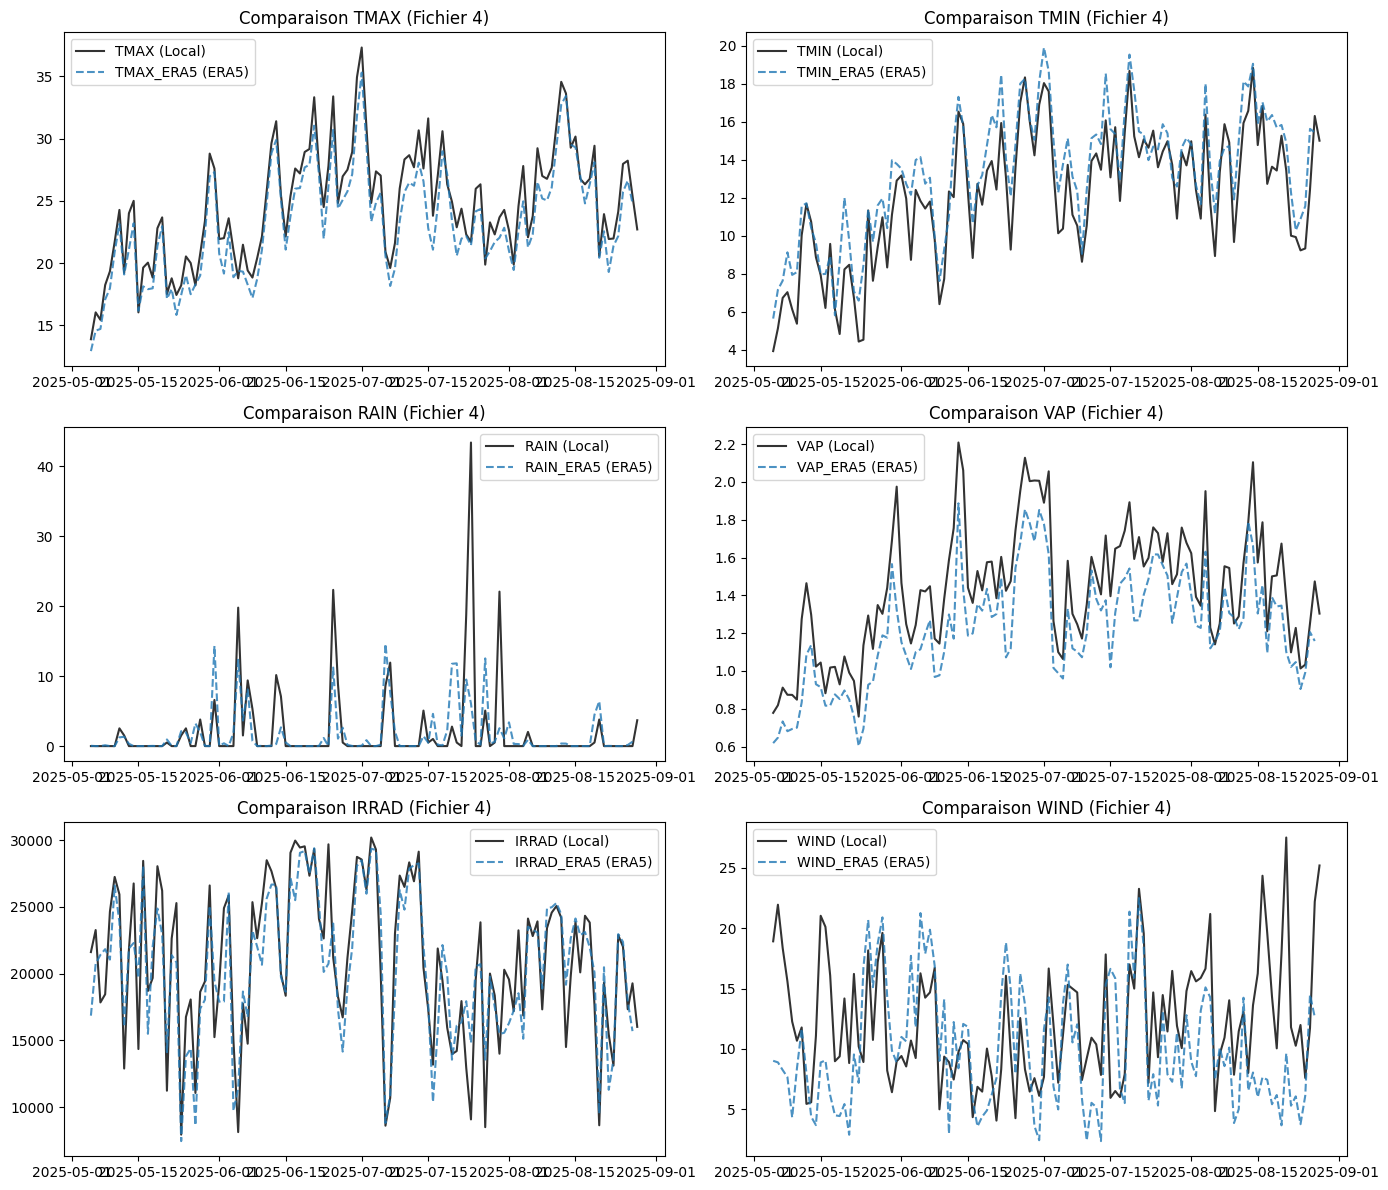


--- Comparaison (115 jours en commun pour Fichier 5) ---
• TMAX:  RMSE = 1.82 | MAE = 1.50 | Biais = 1.46 (Local - ERA5)
• TMIN:  RMSE = 1.72 | MAE = 1.44 | Biais = -1.30 (Local - ERA5)
• RAIN:  RMSE = 4.87 | MAE = 1.80 | Biais = 0.39 (Local - ERA5)
• VAP:  RMSE = 0.24 | MAE = 0.21 | Biais = 0.21 (Local - ERA5)
• IRRAD:  RMSE = 2770.02 | MAE = 2118.19 | Biais = 523.65 (Local - ERA5)
• WIND:  RMSE = 5.93 | MAE = 4.75 | Biais = 2.17 (Local - ERA5)


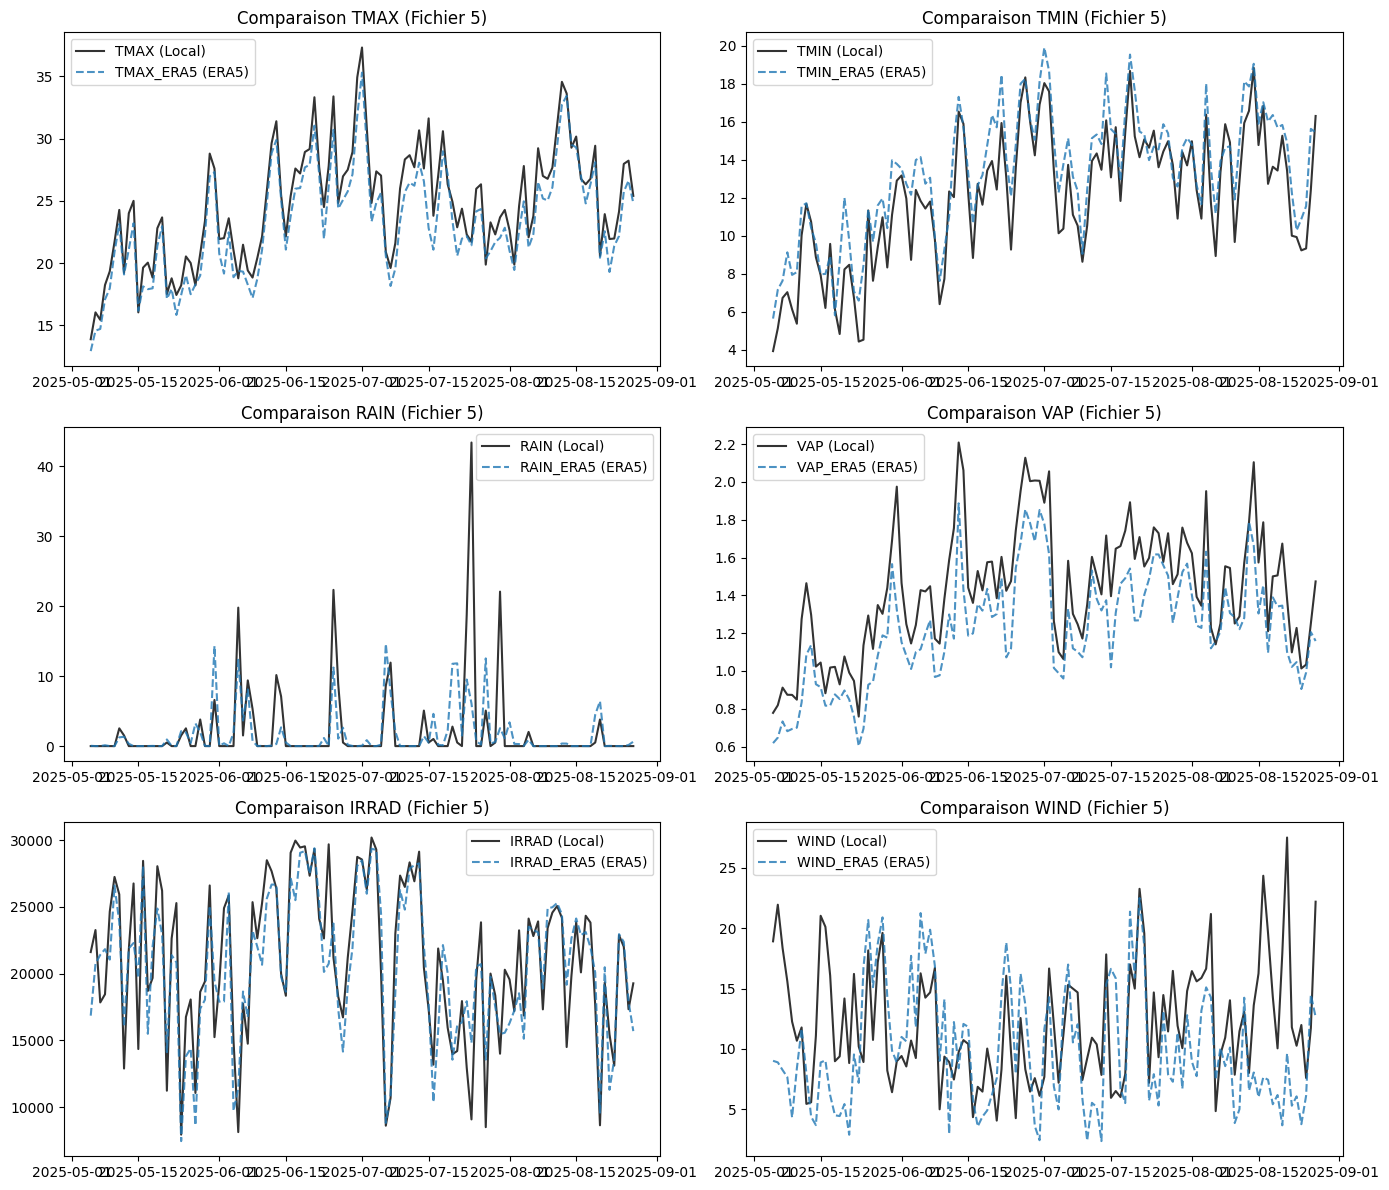

In [6]:
# 1. Charger les données de test Grandvillers
test_list_local = Get_Grandvillers_data(os.path.join(Grandvillers_path, "Grandvillers_satellites"))
# 2. Préparer directement la version de test ERA5 pour chaque fichier
test_list_era5 = []
print("--- PRÉPARATION DU JEU DE TEST ERA5 ---")
for i, df in enumerate(test_list_local):
    df_substituted = prepare_era5_dataset(df, display_name=f"Fichier {i}")
    test_list_era5.append(df_substituted)

In [7]:
all_dfs = get_osiris_data(OSIRIS_DIR)

In [8]:
# for feat_cfg in FEATURE_CONFIGS:
#     feature_cols = feat_cfg["dense"] + feat_cfg["soil"] + feat_cfg["sparse"]
#     osiris_train(feat_cfg, drive_dir, all_dfs)
#     full_eval_grandvillers(feat_cfg, drive_dir, test_list_local, test_list_era5)

In [9]:
### Training
for feat_cfg in FEATURE_CONFIGS:
    # Réassigner les globales
    feature_cols = feat_cfg["dense"] + feat_cfg["soil"] + feat_cfg["sparse"]
    print(f"\n========== FEATURE SET: {feat_cfg['name']} ==========")
    print(f"  Features: {feature_cols}")

    ############### Training ISMN ###############
    full_training(feat_cfg, base_path, drive_dir, MONTHS)

    # ########### Evaluation on Osiris ###############
    # full_eval_osiris(feat_cfg, drive_dir, all_dfs)

    # ########## Evaluation on Grandvillers ###############
    full_eval_grandvillers(feat_cfg, drive_dir, test_list_local, test_list_era5)

    # ############ Fine-Tuning Osiris ###############
    osiris_fine_tuning(feat_cfg, drive_dir, all_dfs)

    ########## Evaluation on Grandvillers ###############
    for i in range(len(feat_cfg["models"])):
        feat_cfg["models"][i] = feat_cfg["models"][i] + "_fine_tuned"
    feat_cfg["name"] = feat_cfg["name"] + "_fine_tuned"
    full_eval_grandvillers(feat_cfg, drive_dir, test_list_local, test_list_era5)


========== FEATURE SET: Network_FT ==========
  Features: ['ET0', 'IRRAD', 'TMIN', 'TMAX', 'VAP', 'WIND', 'RAIN', 'VPD', 'T_RANGE', 'RAIN_CUM_3D', 'RAIN_CUM_7D', 'RAIN_CUM_14D', 'doy_sin', 'doy_cos', 'clay', 'silt', 'bulk', 'sand', 'dem', 'ksat_m_1km', 'dem_slope', 'dem_aspect', 'dem_twi', 'S2_B2', 'S2_B3', 'S2_B4', 'S2_B5', 'S2_B6', 'S2_B7', 'S2_B8', 'S2_B8A', 'S2_B11', 'S2_B12', 'S2_NDVI', 'S2_NDWI', 'S2_SAVI', 'S2_MNDWI', 'S2_NBR', 'S1_VV', 'S1_VH', 'S1_angle', 'S1_VV_over_VH', 'S1_VH_over_VV', 'HLS_B2', 'HLS_B3', 'HLS_B4', 'HLS_B5', 'HLS_B6', 'HLS_B7', 'HLS_B9', 'HLS_B10', 'HLS_B11', 'HLS_NDVI']

====================== NEW DEPTH: 0.1 ======================
Réseaux ['TAHMO', 'TERENO', 'FR_Aqui']: 12 fichiers conservés
Stations: train=3, val=1, test=1
Fichiers chargés: train=7, val=3, test=2
Spatial split: train=7 files, val=3 files, test=2 files
--- Lookback: 7 ---
--- Horizon: 7 ---

=== Training with NB=50000 windows ===

      > Modèle: lstm
Train windows: 15542, Val windows: 57